In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flickr8k/captions.txt
/kaggle/input/flickr8k/Images/3226254560_2f8ac147ea.jpg
/kaggle/input/flickr8k/Images/214543992_ce6c0d9f9b.jpg
/kaggle/input/flickr8k/Images/2366643786_9c9a830db8.jpg
/kaggle/input/flickr8k/Images/3368819708_0bfa0808f8.jpg
/kaggle/input/flickr8k/Images/2190227737_6e0bde2623.jpg
/kaggle/input/flickr8k/Images/2752809449_632cd991b3.jpg
/kaggle/input/flickr8k/Images/3097776588_312932e438.jpg
/kaggle/input/flickr8k/Images/1206506157_c7956accd5.jpg
/kaggle/input/flickr8k/Images/1319634306_816f21677f.jpg
/kaggle/input/flickr8k/Images/2465218087_fca77998c6.jpg
/kaggle/input/flickr8k/Images/3351493005_6e5030f596.jpg
/kaggle/input/flickr8k/Images/2949337912_beba55698b.jpg
/kaggle/input/flickr8k/Images/534886684_a6c9f40fa1.jpg
/kaggle/input/flickr8k/Images/3543600125_223747ef4c.jpg
/kaggle/input/flickr8k/Images/2174206711_11cb712a8d.jpg
/kaggle/input/flickr8k/Images/280706862_14c30d734a.jpg
/kaggle/input/flickr8k/Images/2100735137_05c6079537.jpg
/kaggle/input/f

In [2]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

In [3]:
BASE_DIR = '/kaggle/input/flickr8k'
WORKING_DIR = '/kaggle/working'

In [4]:
model= VGG16()

model= Model(inputs=model.inputs, outputs=model.layers[-2].output)

print(model.summary())

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
features= {}
directory = os.path.join(BASE_DIR, 'Images')

for img_name in tqdm(os.listdir(directory)):
  img_path= directory + '/' + img_name
  image=load_img(img_path , target_size=(224,224))

  image= img_to_array(image)
  image=image.reshape(1, image.shape[0] ,image.shape[1] , image.shape[2])

  image=preprocess_input(image)

  feature=model.predict(image,verbose=0)

  img_id=img_name.split('.')[0]

  features[img_id]= feature

  0%|          | 0/8091 [00:00<?, ?it/s]

I0000 00:00:1732646757.608049      70 service.cc:145] XLA service 0x7a0a180096d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1732646757.608102      70 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1732646757.608106      70 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1732646760.532626      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [6]:
pickle.dump(features, open(os.path.join(WORKING_DIR, 'features.pkl'), 'wb'))

In [7]:
with open(os.path.join(WORKING_DIR, 'features.pkl'), 'rb') as f:
    features = pickle.load(f)


In [8]:
with open(os.path.join(BASE_DIR, 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()

In [9]:
mapping={}

for line in tqdm(captions_doc.split('\n')):
  tokens= line.split(',')
  if len(line)<2:
    continue

  img_id , captions = tokens[0] , tokens[1:]

  img_id=img_id.split('.')[0]
  captions= '.'.join(captions)
  if img_id not in  mapping:
    mapping[img_id]=[]
  mapping[img_id].append(captions)

  0%|          | 0/40456 [00:00<?, ?it/s]

In [10]:
import re

def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            caption = captions[i]
            # Convert to lowercase
            caption = caption.lower()
            # Remove unwanted characters but keep punctuation
            caption = re.sub(r'[^a-zA-Z0-9\s,.!?]', '', caption)
            # Replace multiple spaces with a single space
            caption = re.sub(r'\s+', ' ', caption)
            # Add start and end tokens
            caption = 'startseq ' + caption + ' endseq'
            captions[i] = caption


In [11]:
len(mapping)

8091

In [12]:
mapping['1000268201_693b08cb0e']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [13]:
clean(mapping)

In [14]:
mapping['1000268201_693b08cb0e']

['startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq',
 'startseq a girl going into a wooden building . endseq',
 'startseq a little girl climbing into a wooden playhouse . endseq',
 'startseq a little girl climbing the stairs to her playhouse . endseq',
 'startseq a little girl in a pink dress going into a wooden cabin . endseq']

In [15]:
all_captions=[]
for key in mapping:
  for caption in mapping[key]:
    all_captions.append(caption)

In [16]:
len(all_captions)

40455

In [17]:
all_captions[:10]

['startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq',
 'startseq a girl going into a wooden building . endseq',
 'startseq a little girl climbing into a wooden playhouse . endseq',
 'startseq a little girl climbing the stairs to her playhouse . endseq',
 'startseq a little girl in a pink dress going into a wooden cabin . endseq',
 'startseq a black dog and a spotted dog are fighting endseq',
 'startseq a black dog and a tricolored dog playing with each other on the road . endseq',
 'startseq a black dog and a white dog with brown spots are staring at each other in the street . endseq',
 'startseq two dogs of different breeds looking at each other on the road . endseq',
 'startseq two dogs on pavement moving toward each other . endseq']

In [18]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
vocab_size

8835

In [19]:
max_length = max(len(caption.split()) for caption in all_captions)
max_length

40

In [20]:
img_id=list(mapping.keys())
split= int(len(img_id) * 0.90)
train=img_id[:split]
test=img_id[split:]

In [21]:
def data_generator(data_keys , mapping , features , tokenizer , max_length , vocab_size , batch_size):
  X1 , X2 , y= list() , list() , list()
  n=0
  while 1:
    for key in data_keys:
      n+=1
      captions= mapping[key]
      for caption in captions:
        seq= tokenizer.texts_to_sequences([caption])[0]
        for i in range(1, len(seq)):
          in_seq , out_seq = seq[:i] , seq[i]
          in_seq= pad_sequences([in_seq] , maxlen= max_length , padding='post')[0]
          out_seq= to_categorical([out_seq] , num_classes = vocab_size)[0]

          X1.append(features[key][0])
          X2.append(in_seq)
          y.append(out_seq)
      if n==batch_size:
        X1 , X2 , y= np.array(X1) , np.array(X2) , np.array(y)
        yield {'Image':X1 , 'Text':X2} , y
        X1 , X2 , y= list() , list() , list()
        n=0

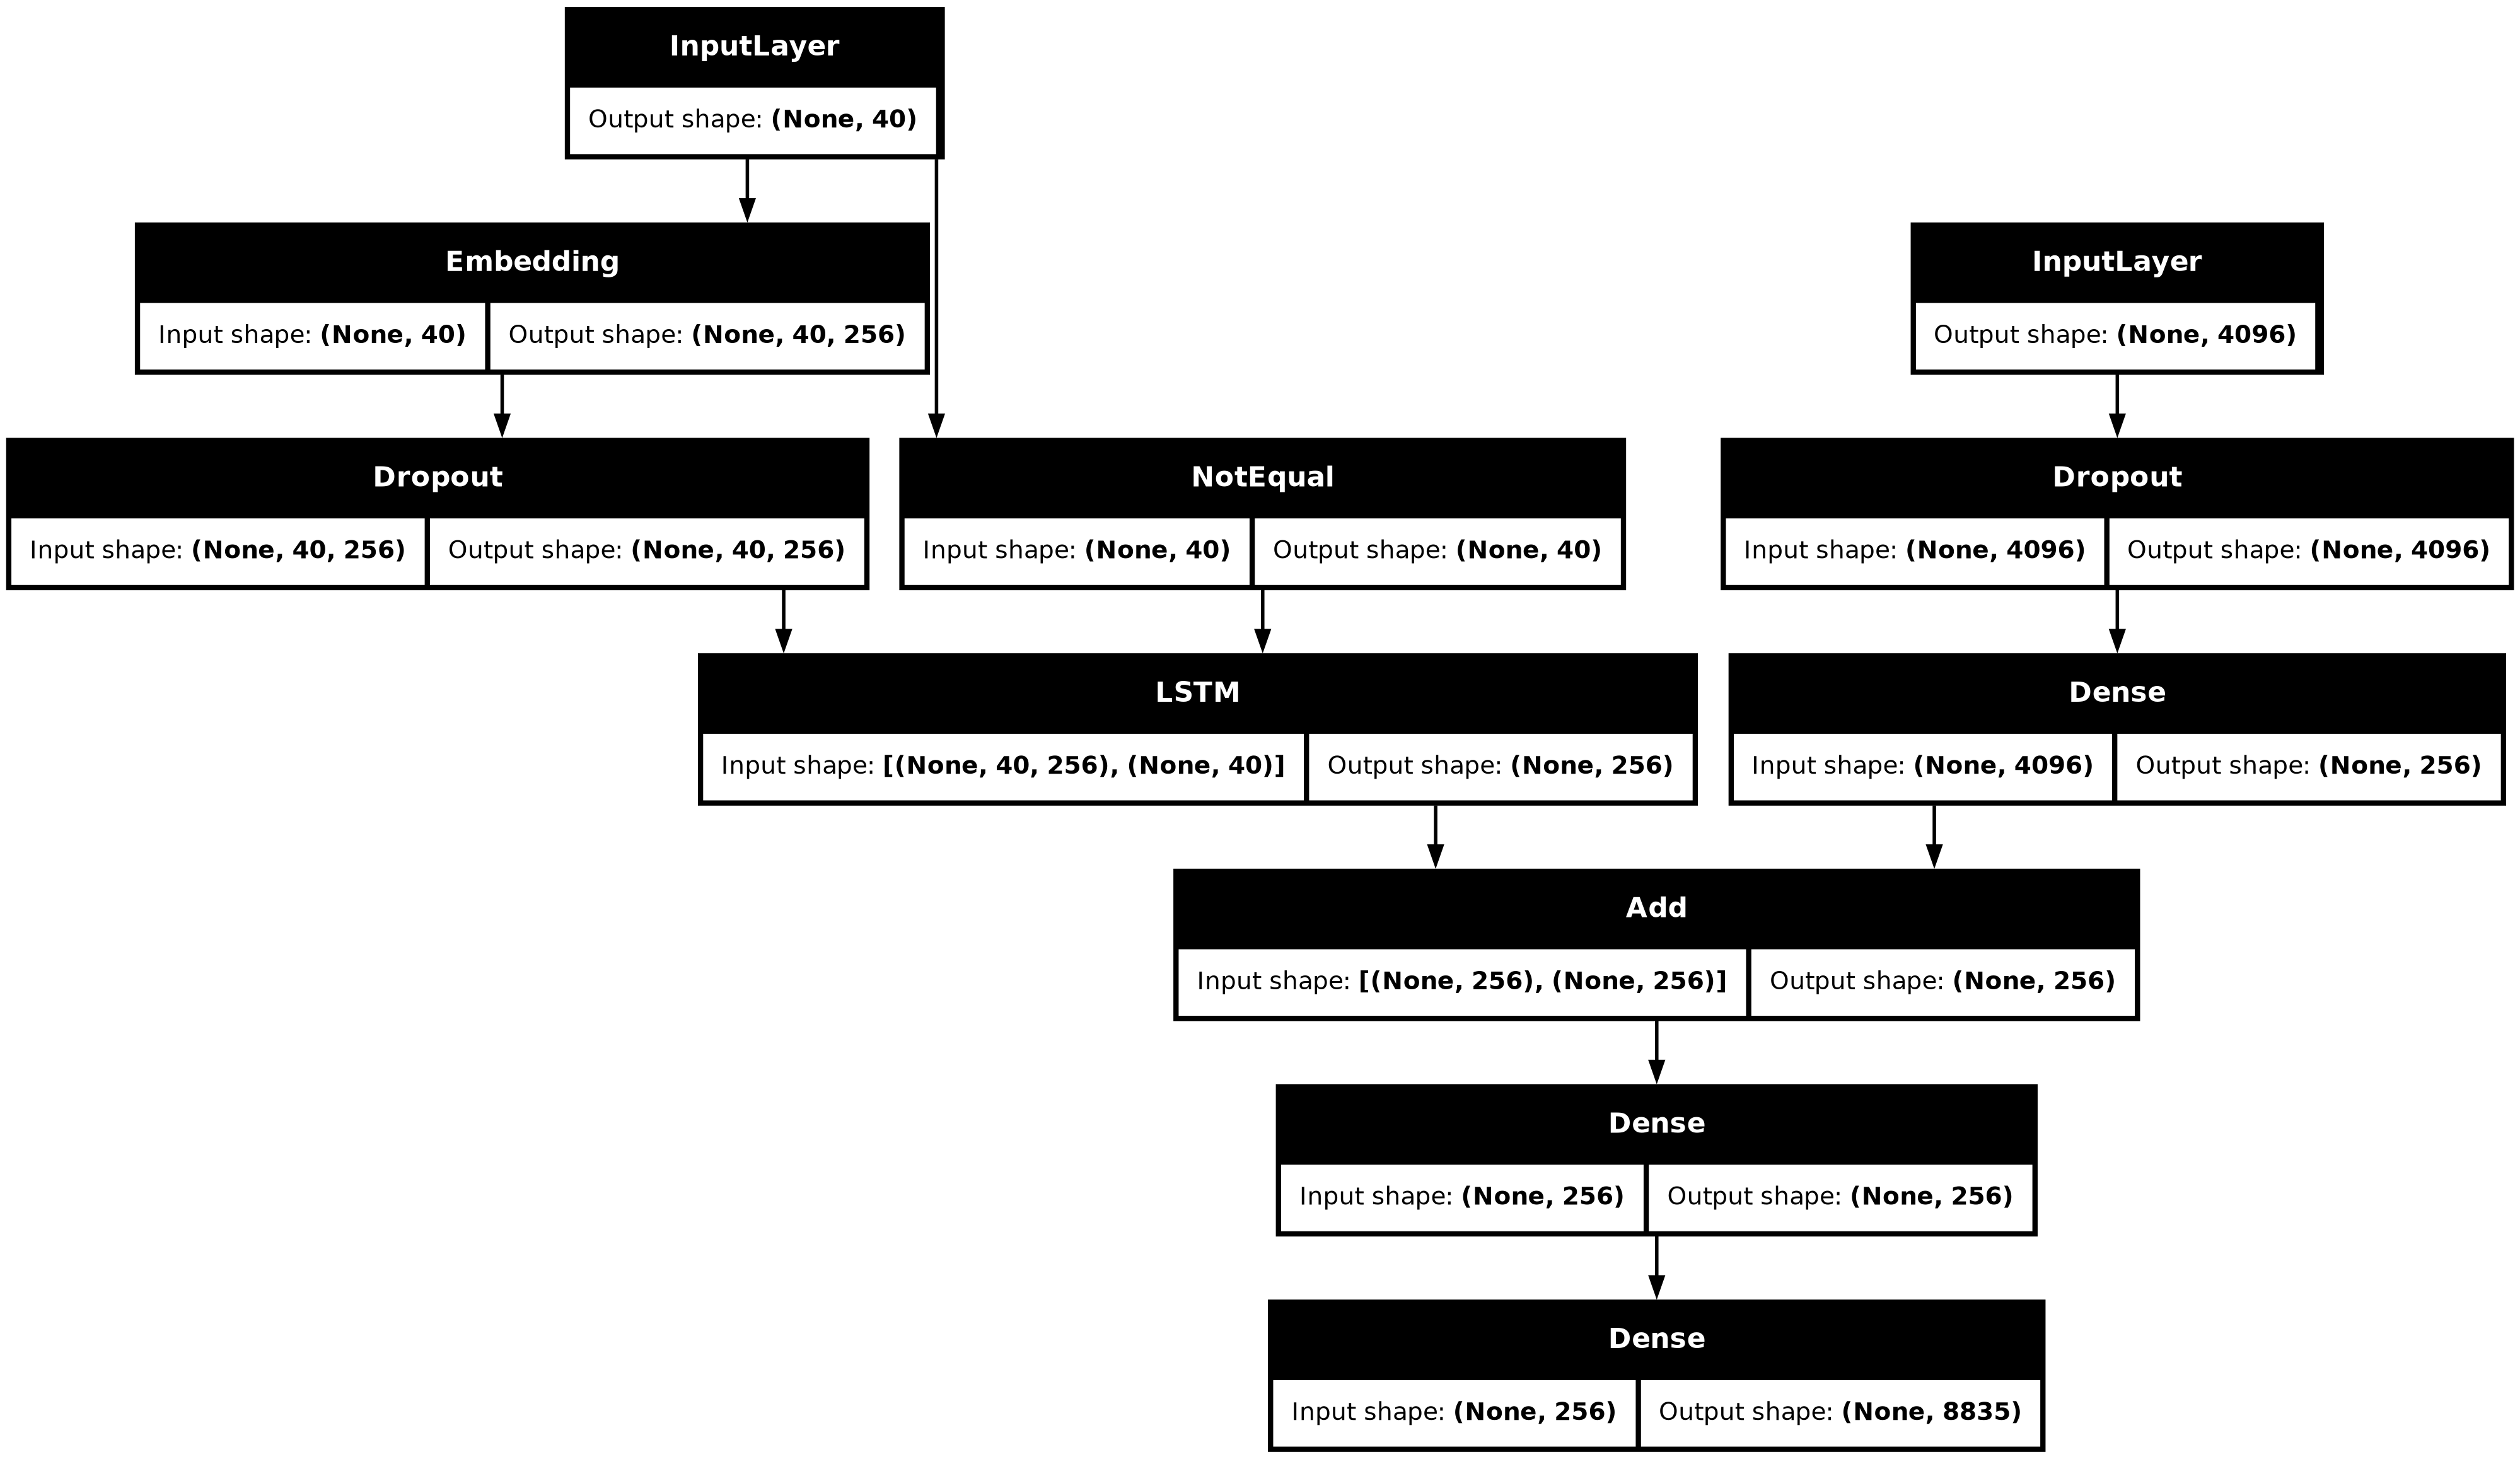

In [22]:
inputs1 = Input(shape=(4096,),name='Image')
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

inputs2 = Input(shape=(max_length,),name='Text')
se1 = Embedding(vocab_size, 256 , mask_zero=True)(inputs2)
se2= Dropout(0.4)(se1)
se3= LSTM(256)(se2)

decoder1= add([fe2 , se3])
decoder2 = Dense(256 , activation='relu')(decoder1)
outputs = Dense(vocab_size , activation='softmax')(decoder2)

model = Model(inputs=[inputs1 , inputs2] , outputs=outputs)
model.compile(loss='categorical_crossentropy' , optimizer='adamax')

plot_model(model , show_shapes=True)

In [23]:
epochs=25
batch_size=34
steps= len(train) //batch_size

for i in range(epochs):
  generator = data_generator(train , mapping , features , tokenizer , max_length , vocab_size , batch_size)
  model.fit(generator , epochs =1 , steps_per_epoch= steps , verbose=1)

214/214 ━━━━━━━━━━━━━━━━━━━━ 68s 300ms/step - loss: 5.6738
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - loss: 4.6656
214/214 ━━━━━━━━━━━━━━━━━━━━ 62s 290ms/step - loss: 4.0762
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 287ms/step - loss: 3.7294
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 284ms/step - loss: 3.5097
214/214 ━━━━━━━━━━━━━━━━━━━━ 60s 281ms/step - loss: 3.3472
214/214 ━━━━━━━━━━━━━━━━━━━━ 60s 281ms/step - loss: 3.2212
214/214 ━━━━━━━━━━━━━━━━━━━━ 62s 290ms/step - loss: 3.1136
214/214 ━━━━━━━━━━━━━━━━━━━━ 63s 294ms/step - loss: 3.0201
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - loss: 2.9363
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - loss: 2.8594
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - loss: 2.7899
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - loss: 2.7276
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 286ms/step - loss: 2.6711
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 284ms/step - loss: 2.6197
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 284ms/step - loss: 2.5734
214/214 ━━━━━━━━━━━━━━━━━━━━ 61s 284ms/step - loss: 2.53

In [24]:
model.save(WORKING_DIR+'/best_model.h5')

In [25]:
def idx_to_word(integer , tokenizer):
  for word , index in tokenizer.word_index.items():
    if index==integer:
      return word
  return None

In [26]:
def predict_caption(model, image , tokenizer , max_length):
  in_text= 'start_seq'
  for i in range(max_length):
    sequence= tokenizer.texts_to_sequences([in_text])[0]
    sequence= pad_sequences([sequence], max_length, padding='post')
    yhat= model.predict([image , sequence],verbose=0)
    yhat=np.argmax(yhat)
    word= idx_to_word(yhat , tokenizer)
    if word is None:
      break
    in_text+=' '+word
    if word=='endseq':
      break
  return in_text

In [27]:
from nltk.translate.bleu_score import corpus_bleu

actual , predicted = list() , list()
for key in tqdm(test):
  captions= mapping[key]
  y_pred= predict_caption(model , features[key] , tokenizer , max_length)
  actual_captions=[caption.split() for caption in captions]
  y_pred= y_pred.split()

  actual.append(actual_captions)
  predicted.append(y_pred)

  print("BLEU1: %f" , corpus_bleu(actual, predicted , weights=(1,0,0,0)))
  print("BLEU2: %f" , corpus_bleu(actual, predicted , weights=(0.5,0,0,0)))


  0%|          | 0/810 [00:00<?, ?it/s]

/opt/conda/lib/python3.10/site-packages/nltk/translate/bleu_score.py:490: UserWarning: 
Corpus/Sentence contains 0 counts of 3-gram overlaps.
BLEU scores might be undesirable; use SmoothingFunction().
  warnings.warn(_msg)


BLEU1: %f 0.2692307692307693
BLEU2: %f 0.5188745216627708
BLEU1: %f 0.3333333333333333
BLEU2: %f 0.5773502691896257
BLEU1: %f 0.43137254901960786
BLEU2: %f 0.6567895774291853
BLEU1: %f 0.4117647058823529
BLEU2: %f 0.6416889479197478
BLEU1: %f 0.43243243243243246
BLEU2: %f 0.6575959492214292
BLEU1: %f 0.4268292682926829
BLEU2: %f 0.6533217188282378
BLEU1: %f 0.4375
BLEU2: %f 0.6614378277661477
BLEU1: %f 0.45714285714285713
BLEU2: %f 0.6761234037828132
BLEU1: %f 0.4406779661016949
BLEU2: %f 0.6638357975446149
BLEU1: %f 0.4249768279514098
BLEU2: %f 0.641388141980663
BLEU1: %f 0.4294333784465945
BLEU2: %f 0.6453828918937665
BLEU1: %f 0.43296746327843044
BLEU2: %f 0.6444360527220357
BLEU1: %f 0.44966720135836846
BLEU2: %f 0.6576356130163277
BLEU1: %f 0.4404129589704782
BLEU2: %f 0.6520949595331051
BLEU1: %f 0.42648737827876637
BLEU2: %f 0.6365741095029936
BLEU1: %f 0.4288213818034154
BLEU2: %f 0.6394371601002246
BLEU1: %f 0.4375655352703285
BLEU2: %f 0.6451551846622187
BLEU1: %f 0.430717085

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    
    img_id= image_name.split('.')[0]
    img_path= os.path.join(BASE_DIR, "Images" , image_name)
    image=Image.open(img_path)
    captions=mapping[img_id]
    print('...Actual...')
    for caption in captions:
        print(caption)
    y_pred= predict_caption(model , features[img_id] , tokenizer , max_length)
    print('...Predicted...')
    print(y_pred)
    plt.imshow(image)

...Actual...
startseq a black dog and a spotted dog are fighting endseq
startseq a black dog and a tricolored dog playing with each other on the road . endseq
startseq a black dog and a white dog with brown spots are staring at each other in the street . endseq
startseq two dogs of different breeds looking at each other on the road . endseq
startseq two dogs on pavement moving toward each other . endseq
...Predicted...
start_seq two small dogs play in the grass endseq


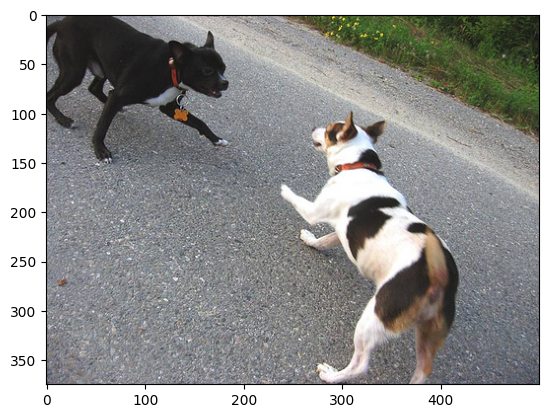

In [29]:
generate_caption("1001773457_577c3a7d70.jpg")

...Actual...
startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq
startseq a girl going into a wooden building . endseq
startseq a little girl climbing into a wooden playhouse . endseq
startseq a little girl climbing the stairs to her playhouse . endseq
startseq a little girl in a pink dress going into a wooden cabin . endseq
...Predicted...
start_seq a playhouse endseq


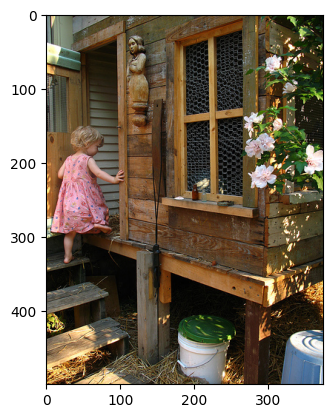

In [30]:
generate_caption("1000268201_693b08cb0e.jpg")

...Actual...
startseq a child playing on a rope net . endseq
startseq a little girl climbing on red roping . endseq
startseq a little girl in pink climbs a rope bridge at the park . endseq
startseq a small child grips onto the red ropes at the playground . endseq
startseq the small child climbs on a red ropes on a playground . endseq
...Predicted...
start_seq ropes ropes endseq


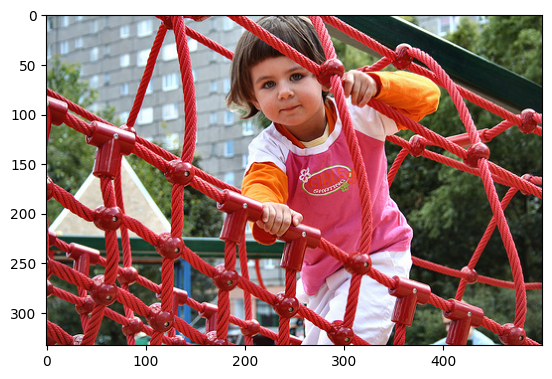

In [31]:
generate_caption("1007320043_627395c3d8.jpg")